%share of AI roles with perk X = %share of perk X in general + %share of AI roles + log(size of occupation-year) + log(salary of AI roles)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
from IPython.core.display import HTML

In [3]:
import numpy as np

In [4]:
# import stargazer
from stargazer.stargazer import Stargazer

In [5]:
import sys
import os

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)

In [6]:
from package_files.benefits_defns import *

In [7]:
df = pd.read_csv('../exports/occ_year_coeff_analysis.csv')

In [8]:
pd.set_option('display.max_columns', None)

In [8]:
df[(df['Occupation']=="Architecture and Engineering Occupations") & (df['Year']==2019)]

,Benefit,Occupation,Year,AI Coefficient,Error,P-Value,SOC_2021_2_NAME,YEAR,AI Demand,AI Demand % Change,PRIOR YEAR % CHANGE,LOG_SALARY_ai,SALARY_ai,LOG_SALARY_non_ai,SALARY_non_ai,Salary (Log) Premium,SALARY_PREMIUM,DURATION_CALC_ai,DURATION_CALC_non_ai,MEAN SALARY,job_count,Prevalence: Tuition Assistance,Prevalence: Tuition Assistance (AI),Prevalence: Tuition Assistance (Non-AI),Prevalence: Paid Leave,Prevalence: Paid Leave (AI),Prevalence: Paid Leave (Non-AI),Prevalence: Health and Wellbeing,Prevalence: Health and Wellbeing (AI),Prevalence: Health and Wellbeing (Non-AI),Prevalence: Parental Leave,Prevalence: Parental Leave (AI),Prevalence: Parental Leave (Non-AI),Prevalence: Workplace Culture,Prevalence: Workplace Culture (AI),Prevalence: Workplace Culture (Non-AI),Prevalence: Remote Work,Prevalence: Remote Work (AI),Prevalence: Remote Work (Non-AI)
0,EDU_ASSISTANCE,Architecture and Engineering Occupations,2019,-0.378773,0.202133,0.061,Architecture and Engineering Occupations,2019,2.031486,24.871731,NaN,11.443344,97865.619048,11.108535,73760.300943,103.013976,132.680612,61.510441,59.027063,73966.078049,42432,4.645079,3.016241,4.678855,11.566742,8.236659,11.635795,3.113216,1.62413,3.144094,0.782428,1.972158,0.757758,5.56891,10.788863,5.460669,2.348773,3.415783,2.32633
90,WLB,Architecture and Engineering Occupations,2019,-0.155173,0.112814,0.169,Architecture and Engineering Occupations,2019,2.031486,24.871731,NaN,11.443344,97865.619048,11.108535,73760.300943,103.013976,132.680612,61.510441,59.027063,73966.078049,42432,4.645079,3.016241,4.678855,11.566742,8.236659,11.635795,3.113216,1.62413,3.144094,0.782428,1.972158,0.757758,5.56891,10.788863,5.460669,2.348773,3.415783,2.32633
180,PAID_LEAVE,Architecture and Engineering Occupations,2019,-0.303556,0.125737,0.016,Architecture and Engineering Occupations,2019,2.031486,24.871731,NaN,11.443344,97865.619048,11.108535,73760.300943,103.013976,132.680612,61.510441,59.027063,73966.078049,42432,4.645079,3.016241,4.678855,11.566742,8.236659,11.635795,3.113216,1.62413,3.144094,0.782428,1.972158,0.757758,5.56891,10.788863,5.460669,2.348773,3.415783,2.32633
270,HEALTH_WELLBEING,Architecture and Engineering Occupations,2019,-0.590114,0.272715,0.030,Architecture and Engineering Occupations,2019,2.031486,24.871731,NaN,11.443344,97865.619048,11.108535,73760.300943,103.013976,132.680612,61.510441,59.027063,73966.078049,42432,4.645079,3.016241,4.678855,11.566742,8.236659,11.635795,3.113216,1.62413,3.144094,0.782428,1.972158,0.757758,5.56891,10.788863,5.460669,2.348773,3.415783,2.32633
360,PARENTAL_LEAVE,Architecture and Engineering Occupations,2019,0.958254,0.256600,0.000,Architecture and Engineering Occupations,2019,2.031486,24.871731,NaN,11.443344,97865.619048,11.108535,73760.300943,103.013976,132.680612,61.510441,59.027063,73966.078049,42432,4.645079,3.016241,4.678855,11.566742,8.236659,11.635795,3.113216,1.62413,3.144094,0.782428,1.972158,0.757758,5.56891,10.788863,5.460669,2.348773,3.415783,2.32633
450,CULTURE,Architecture and Engineering Occupations,2019,0.568717,0.114443,0.000,Architecture and Engineering Occupations,2019,2.031486,24.871731,NaN,11.443344,97865.619048,11.108535,73760.300943,103.013976,132.680612,61.510441,59.027063,73966.078049,42432,4.645079,3.016241,4.678855,11.566742,8.236659,11.635795,3.113216,1.62413,3.144094,0.782428,1.972158,0.757758,5.56891,10.788863,5.460669,2.348773,3.415783,2.32633
540,wfh_wham,Architecture and Engineering Occupations,2019,0.366585,0.194626,0.060,Architecture and Engineering Occupations,2019,2.031486,24.871731,NaN,11.443344,97865.619048,11.108535,73760.300943,103.013976,132.680612,61.510441,59.027063,73966.078049,42432,4.645079,3.016241,4.678855,11.566742,8.236659,11.635795,3.113216,1.62413,3.144094,0.782428,1.972158,0.757758,5.56891,10.788863,5.460669,2.348773,3.415783,2.32633


In [7]:
df

,Benefit,Occupation,Year,AI Coefficient,Error,P-Value,SOC_2021_2_NAME,YEAR,AI Demand,AI Demand % Change,PRIOR YEAR % CHANGE,LOG_SALARY_ai,SALARY_ai,LOG_SALARY_non_ai,SALARY_non_ai,Salary (Log) Premium,SALARY_PREMIUM,DURATION_CALC_ai,DURATION_CALC_non_ai,MEAN SALARY,job_count,Prevalence: Tuition Assistance,Prevalence: Tuition Assistance (AI),Prevalence: Tuition Assistance (Non-AI),Prevalence: Paid Leave,Prevalence: Paid Leave (AI),Prevalence: Paid Leave (Non-AI),Prevalence: Health and Wellbeing,Prevalence: Health and Wellbeing (AI),Prevalence: Health and Wellbeing (Non-AI),Prevalence: Parental Leave,Prevalence: Parental Leave (AI),Prevalence: Parental Leave (Non-AI),Prevalence: Workplace Culture,Prevalence: Workplace Culture (AI),Prevalence: Workplace Culture (Non-AI),Prevalence: Remote Work,Prevalence: Remote Work (AI),Prevalence: Remote Work (Non-AI)
0,EDU_ASSISTANCE,Architecture and Engineering Occupations,2019,-0.378773,0.202133,0.061,Architecture and Engineering Occupations,2019,2.031486,24.871731,NaN,11.443344,97865.619048,11.108535,73760.300943,103.013976,132.680612,61.510441,59.027063,73966.078049,42432,4.645079,3.016241,4.678855,11.566742,8.236659,11.635795,3.113216,1.624130,3.144094,0.782428,1.972158,0.757758,5.568910,10.788863,5.460669,2.348773,3.415783,2.326330
1,EDU_ASSISTANCE,Architecture and Engineering Occupations,2021,-0.191725,0.140017,0.171,Architecture and Engineering Occupations,2021,2.278018,15.179062,-2.642404,11.521036,107050.060606,11.095518,73216.702324,103.835046,146.209891,61.420229,63.841780,73671.056972,42098,7.187990,5.839416,7.219427,20.221863,11.261731,20.430735,3.722267,2.294056,3.755560,2.598698,3.232534,2.583923,10.442301,24.400417,10.116921,8.357362,14.465409,8.215270
2,EDU_ASSISTANCE,Architecture and Engineering Occupations,2022,-0.309976,0.108110,0.004,Architecture and Engineering Occupations,2022,2.446456,7.394079,15.179062,11.600475,115932.657459,11.235284,83342.705232,103.250399,139.103545,54.149606,55.015043,83890.460953,57103,8.840166,6.800286,8.891322,22.760626,15.533286,22.941873,4.591703,2.219041,4.651205,3.991034,5.153901,3.961871,15.806525,35.146743,15.321509,14.685004,18.168605,14.597810
3,EDU_ASSISTANCE,Architecture and Engineering Occupations,2020,-0.152420,0.196615,0.438,Architecture and Engineering Occupations,2020,1.977806,-2.642404,24.871731,11.428493,100957.585366,11.075966,72630.480348,103.182813,139.001677,60.158371,59.307465,72858.029585,33522,5.271165,4.223228,5.292310,16.428017,9.502262,16.567759,2.890639,1.659125,2.915487,1.312571,1.357466,1.311665,6.691128,18.853695,6.445723,4.442167,13.698630,4.255188
4,EDU_ASSISTANCE,Architecture and Engineering Occupations,2018,0.043941,0.219785,0.842,Architecture and Engineering Occupations,2018,1.626858,NaN,NaN,11.279748,85233.255814,11.095357,72599.869117,101.661881,117.401390,64.000000,61.662382,72708.646776,40569,3.307944,3.333333,3.307525,8.255072,6.060606,8.291363,1.466637,1.818182,1.460823,0.276073,0.151515,0.278133,4.777047,7.121212,4.738280,0.000000,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
610,wfh_wham,Transportation and Material Moving Occupations,2019,-18.205488,17234.764550,0.999,Transportation and Material Moving Occupations,2019,0.033652,-18.600785,NaN,10.485831,38192.625000,10.591160,44183.609987,99.005500,86.440707,59.806452,61.214999,44182.104241,92120,4.829570,0.000000,4.831196,21.079027,12.903226,21.081780,3.222970,3.225806,3.222969,0.578593,0.000000,0.578788,2.248155,3.225806,2.247825,0.385060,0.000000,0.385194
611,wfh_wham,Transportation and Material Moving Occupations,2021,0.533101,0.527071,0.312,Transportation and Material Moving Occupations,2021,0.067199,149.616383,-20.001353,10.663532,48247.636364,10.664556,46919.891740,99.990403,102.829812,66.026549,65.484129,46920.261844,168157,7.579227,6.194690,7.580158,36.863764,11.504425,36.880817,7.994910,4.424779,7.997310,3.968315,5.

In [13]:
# add column for log job count
df['Log Job Count'] = df['job_count'].apply(lambda x: np.log(x))

%share of AI roles with perk X = %share of perk X in general + %share of AI roles + log(size of occupation-year) + log(salary of AI roles)

# Run Models

In [31]:

# benefit_models = {}
benefit_models = []
for benefit in benefits4:
    benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence', 'LOG_SALARY_ai':'Mean Log AI Salary'}, inplace=True)

    label = benefits_labels_map[benefit]

    X = benefit_df[[f'Overall Benefit Prevalence', 'AI Demand', 'Log Job Count', 'Mean Log AI Salary']]
    y = benefit_df[f'Prevalence: {label} (AI)']

    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    # benefit_models.setdefault(benefit, []).append(model)
    benefit_models.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
                                     OLS Regression Results                                    
Dep. Variable:     Prevalence: Tuition Assistance (AI)   R-squared:                       0.365
Model:                                             OLS   Adj. R-squared:                  0.335
Method:                                  Least Squares   F-statistic:                     12.23
Date:                                 Sun, 27 Oct 2024   Prob (F-statistic):           6.74e-08
Time:                                         20:13:36   Log-Likelihood:                -221.04
No. Observations:                                   90   AIC:                             452.1
Df Residuals:                                       85   BIC:                             464.6
Df Model:                                            4                                         
Covariance Type:                             nonrobust                                         
                         

# Display Results

In [27]:
stargazer = Stargazer(benefit_models)
display(HTML(stargazer.render_html()))

In [33]:
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(benefit_models)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column

with open(f'../exports/occ_year_final_model.tex', 'w') as f:
    f.write(stargazer.render_latex())
# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))


In [17]:
# for benefit in benefits4:
#     stargazer = Stargazer(benefit_models[benefit])
#     stargazer.title(f'Coefficients for {benefits_labels_map[benefit]}')
#     display(HTML(stargazer.render_html()))
#     # # export to latex
#     # with open(f'../exports/occ_year_coeff_{benefit}.tex', 'w') as f:
#     #     f.write(stargazer.render_latex())

# Remote Keywords

In [71]:
df = pd.read_csv('../exports/occ_year_data/occ_year_analysis_remotekw.csv')

In [72]:
df

,SOC_2021_2_NAME,YEAR,AI Demand,MEAN SALARY,AI Demand % Change,PRIOR YEAR % CHANGE,LOG_SALARY_ai,SALARY_ai,DURATION_CALC_ai,MEDIAN_LOG_SALARY_ai,MEDIAN_SALARY_ai,LOG_SALARY_non_ai,SALARY_non_ai,DURATION_CALC_non_ai,MEDIAN_LOG_SALARY_non_ai,MEDIAN_SALARY_non_ai,Salary (Log) Premium,SALARY_PREMIUM,job_count,Prevalence: Tuition Assistance,Prevalence: Tuition Assistance (AI),Prevalence: Tuition Assistance (Non-AI),Prevalence: Paid Leave,Prevalence: Paid Leave (AI),Prevalence: Paid Leave (Non-AI),Prevalence: Health and Wellbeing,Prevalence: Health and Wellbeing (AI),Prevalence: Health and Wellbeing (Non-AI),Prevalence: Parental Leave,Prevalence: Parental Leave (AI),Prevalence: Parental Leave (Non-AI),Prevalence: Workplace Culture,Prevalence: Workplace Culture (AI),Prevalence: Workplace Culture (Non-AI),Prevalence: Remote Work,Prevalence: Remote Work (AI),Prevalence: Remote Work (Non-AI),Prevalence: Remote Keywords,Prevalence: Remote Keywords (AI),Prevalence: Remote Keywords (Non-AI),Log Job Count
0,Architecture and Engineering Occupations,2018,1.626858,72708.646776,NaN,NaN,11.279748,85233.255814,64.000000,11.329003,83200.0,11.095357,72599.869117,61.662382,11.156251,70000.0,101.661881,117.401390,40569,3.307944,3.333333,3.307525,8.255072,6.060606,8.291363,1.466637,1.818182,1.460823,0.276073,0.151515,0.278133,4.777047,7.121212,4.738280,0.000000,NaN,0.000000,1.971949,1.363636,1.982009,10.610760
1,Architecture and Engineering Occupations,2019,2.031486,73966.078049,24.871731,NaN,11.443344,97865.619048,61.510441,11.461632,95000.0,11.108535,73760.300943,59.027063,11.166484,70720.0,103.013976,132.680612,42432,4.645079,3.016241,4.678855,11.566742,8.236659,11.635795,3.113216,1.624130,3.144094,0.782428,1.972158,0.757758,5.568910,10.788863,5.460669,2.348773,3.415783,2.326330,2.104544,3.944316,2.066394,10.655658
2,Architecture and Engineering Occupations,2020,1.977806,72858.029585,-2.642404,24.871731,11.428493,100957.585366,60.158371,11.487608,97500.0,11.075966,72630.480348,59.307465,11.105859,66560.0,103.182813,139.001677,33522,5.271165,4.223228,5.292310,16.428017,9.502262,16.567759,2.890639,1.659125,2.915487,1.312571,1.357466,1.311665,6.691128,18.853695,6.445723,4.442167,13.698630,4.255188,3.872084,11.915535,3.709790,10.419957
3,Architecture and Engineering Occupations,2021,2.278018,73671.056972,15.179062,-2.642404,11.521036,107050.060606,61.420229,11.556942,104500.0,11.095518,73216.702324,63.841780,11.119883,67500.0,103.835046,146.209891,42098,7.187990,5.839416,7.219427,20.221863,11.261731,20.430735,3.722267,2.294056,3.755560,2.598698,3.232534,2.583923,10.442301,24.400417,10.116921,8.357362,14.465409,8.215270,6.670151,9.176225,6.611731,10.647756
4,Architecture and Engineering Occupations,2022,2.446456,83890.460953,7.394079,15.179062,11.600475,115932.657459,54.149606,11.556942,104500.0,11.235284,83342.705232,55.015043,11.277203,79000.0,103.250399,139.103545,57103,8.840166,6.800286,8.891322,22.760626,15.533286,22.941873,4.591703,2.219041,4.651205,3.991034,5.153901,3.961871,15.806525,35.146743,15.321509,14.685004,18.168605,14.597810,10.475807,13.886901,10.390263,10.952612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,Transportation and Material Moving Occupations,2019,0.033652,44182.104241,-18.600785,NaN,10.485831,38192.625000,59.806452,10.450209,34663.0,10.591160,44183.609987,61.214999,10.473337,35360.0,99.005500,86.440707,92120,4.829570,0.000000,4.831196,21.079027,12.903226,21.081780,3.222970,3.225806,3.222969,0.578593,0.000000,0.578788,2.248155,3.225806,2.247825,0.385060,0.000000,0.385194,0.574251,0.000000,0.574444,11.430847
86,Transportation and Material Moving Occupations,2020,0.026921,42269.295590,-20.001353,-18.600785,10.529685,40678.900000,55.210526,10.404093,33020.0,10.562795,42269.527535,62.520019,10.425134,33696.0,99.686540,96.236940,141154,5.673945,5.263158,5.674055,29.072502,18.421053,29.075371,7.670346,2.6315

In [35]:
benefit_models = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df = benefit_df[benefit_df[f'Prevalence: {benefits_labels_map[benefit]} (AI)'].notna()]
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence', 'LOG_SALARY_ai':'Mean Log AI Salary'}, inplace=True)

    label = benefits_labels_map[benefit]

    X = benefit_df[[f'Overall Benefit Prevalence', 'AI Demand', 'Log Job Count', 'MEDIAN SALARY_ai']]
    y = benefit_df[f'Prevalence: {label} (AI)']

    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    # benefit_models.setdefault(benefit, []).append(model)
    benefit_models.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
                                     OLS Regression Results                                    
Dep. Variable:     Prevalence: Tuition Assistance (AI)   R-squared:                       0.365
Model:                                             OLS   Adj. R-squared:                  0.335
Method:                                  Least Squares   F-statistic:                     12.23
Date:                                 Fri, 01 Nov 2024   Prob (F-statistic):           6.74e-08
Time:                                         16:22:52   Log-Likelihood:                -221.04
No. Observations:                                   90   AIC:                             452.1
Df Residuals:                                       85   BIC:                             464.6
Df Model:                                            4                                         
Covariance Type:                             nonrobust                                         
                         

In [32]:
benefit_models

In [36]:
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(benefit_models)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))


# Model Configuration

## Baseline: Year and Overall Benefit Prevalence

In [46]:
baseline_models = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df = benefit_df[benefit_df[f'Prevalence: {benefits_labels_map[benefit]} (AI)'].notna()]
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence', 'LOG_SALARY_ai':'Mean Log AI Salary'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]

    X = benefit_df[[f'Overall Benefit Prevalence']]
    y = benefit_df[f'Prevalence: {label} (AI)']
    year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    print(year_dummies)
    X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    print(X)
    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    # benefit_models.setdefault(benefit, []).append(model)
    baseline_models.append(model)
    # Print the summary of the regression
    print(model.summary())

    Year_2018  Year_2020  Year_2021  Year_2022  Year_2023
0        True      False      False      False      False
1       False      False      False      False      False
2       False       True      False      False      False
3       False      False       True      False      False
4       False      False      False       True      False
..        ...        ...        ...        ...        ...
85      False      False      False      False      False
86      False       True      False      False      False
87      False      False       True      False      False
88      False      False      False       True      False
89      False      False      False      False       True

[90 rows x 5 columns]
    Overall Benefit Prevalence  Year_2018  Year_2020  Year_2021  Year_2022  \
0                     3.307944          1          0          0          0   
1                     4.645079          0          0          0          0   
2                     5.271165          0      

In [47]:
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(baseline_models)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))


## With AI Demand

In [51]:
models2 = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df = benefit_df[benefit_df[f'Prevalence: {benefits_labels_map[benefit]} (AI)'].notna()]
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence', 'LOG_SALARY_ai':'Mean Log AI Salary'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]

    X = benefit_df[[f'Overall Benefit Prevalence', 'AI Demand']]
    y = benefit_df[f'Prevalence: {label} (AI)']
    year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    # print(year_dummies)
    X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    # print(X)
    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    # benefit_models.setdefault(benefit, []).append(model)
    models2.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
                                     OLS Regression Results                                    
Dep. Variable:     Prevalence: Tuition Assistance (AI)   R-squared:                       0.554
Model:                                             OLS   Adj. R-squared:                  0.516
Method:                                  Least Squares   F-statistic:                     14.57
Date:                                 Fri, 01 Nov 2024   Prob (F-statistic):           3.51e-12
Time:                                         16:46:07   Log-Likelihood:                -205.12
No. Observations:                                   90   AIC:                             426.2
Df Residuals:                                       82   BIC:                             446.2
Df Model:                                            7                                         
Covariance Type:                             nonrobust                                         
                         

In [50]:
models2

[]

In [52]:
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(models2)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))


## + % Demand Change

In [56]:
models3 = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence', 'LOG_SALARY_ai':'Mean Log AI Salary'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]
    X_cols = [f'Overall Benefit Prevalence', 'AI Demand', 'AI Demand % Change']
    y_col = [f'Prevalence: {label} (AI)']
    benefit_df = benefit_df.dropna(subset=X_cols + y_col)
    X = benefit_df[X_cols]
    y = benefit_df[y_col]
    year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    # print(year_dummies)
    X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    # print(X)
    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    # benefit_models.setdefault(benefit, []).append(model)
    models3.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
                                     OLS Regression Results                                    
Dep. Variable:     Prevalence: Tuition Assistance (AI)   R-squared:                       0.579
Model:                                             OLS   Adj. R-squared:                  0.534
Method:                                  Least Squares   F-statistic:                     13.14
Date:                                 Fri, 01 Nov 2024   Prob (F-statistic):           1.61e-10
Time:                                         16:57:25   Log-Likelihood:                -171.34
No. Observations:                                   75   AIC:                             358.7
Df Residuals:                                       67   BIC:                             377.2
Df Model:                                            7                                         
Covariance Type:                             nonrobust                                         
                         

In [57]:
models3

In [58]:
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(models3)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))


## % Change Substitute for AI Demand

In [59]:
models3b = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence', 'LOG_SALARY_ai':'Mean Log AI Salary'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]
    X_cols = [f'Overall Benefit Prevalence', 'AI Demand % Change']
    y_col = [f'Prevalence: {label} (AI)']
    benefit_df = benefit_df.dropna(subset=X_cols + y_col)
    X = benefit_df[X_cols]
    y = benefit_df[y_col]
    year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    # print(year_dummies)
    X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    # print(X)
    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    # benefit_models.setdefault(benefit, []).append(model)
    models3b.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
                                     OLS Regression Results                                    
Dep. Variable:     Prevalence: Tuition Assistance (AI)   R-squared:                       0.563
Model:                                             OLS   Adj. R-squared:                  0.525
Method:                                  Least Squares   F-statistic:                     14.62
Date:                                 Fri, 01 Nov 2024   Prob (F-statistic):           1.22e-10
Time:                                         17:03:06   Log-Likelihood:                -172.67
No. Observations:                                   75   AIC:                             359.3
Df Residuals:                                       68   BIC:                             375.6
Df Model:                                            6                                         
Covariance Type:                             nonrobust                                         
                         

In [60]:
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(models3b)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))


## Median Salary

In [79]:
models4 = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence', 'LOG_SALARY_ai':'Mean Log AI Salary'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]
    X_cols = [f'Overall Benefit Prevalence', 'AI Demand', 'MEDIAN_SALARY_ai']
    y_col = [f'Prevalence: {label} (AI)']
    benefit_df = benefit_df.dropna(subset=X_cols + y_col)
    X = benefit_df[X_cols]
    y = benefit_df[y_col]
    year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    # print(year_dummies)
    X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    # print(X)
    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    # benefit_models.setdefault(benefit, []).append(model)
    models4.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
                                     OLS Regression Results                                    
Dep. Variable:     Prevalence: Tuition Assistance (AI)   R-squared:                       0.559
Model:                                             OLS   Adj. R-squared:                  0.516
Method:                                  Least Squares   F-statistic:                     12.85
Date:                                 Fri, 01 Nov 2024   Prob (F-statistic):           9.23e-12
Time:                                         17:39:08   Log-Likelihood:                -204.63
No. Observations:                                   90   AIC:                             427.3
Df Residuals:                                       81   BIC:                             449.8
Df Model:                                            8                                         
Covariance Type:                             nonrobust                                         
                         

In [80]:
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(models4)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))


In [77]:
models_salary = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence', 'LOG_SALARY_ai':'Mean Log AI Salary'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]
    X_cols = [f'MEDIAN_LOG_SALARY_ai']
    y_col = [f'Prevalence: {label} (AI)']
    benefit_df = benefit_df.dropna(subset=X_cols + y_col)
    X = benefit_df[X_cols]
    y = benefit_df[y_col]
    year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    # print(year_dummies)
    # X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    # print(X)
    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    # benefit_models.setdefault(benefit, []).append(model)
    models_salary.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
                                     OLS Regression Results                                    
Dep. Variable:     Prevalence: Tuition Assistance (AI)   R-squared:                       0.024
Model:                                             OLS   Adj. R-squared:                  0.013
Method:                                  Least Squares   F-statistic:                     2.129
Date:                                 Fri, 01 Nov 2024   Prob (F-statistic):              0.148
Time:                                         17:36:25   Log-Likelihood:                -240.42
No. Observations:                                   90   AIC:                             484.8
Df Residuals:                                       88   BIC:                             489.8
Df Model:                                            1                                         
Covariance Type:                             nonrobust                                         
                         

In [78]:
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(models_salary)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))


In [68]:
df['MEDIAN SALARY_ai'].describe()

count        90.000000
mean      80753.538889
std       37439.280812
min       20800.000000
25%       52525.000000
50%       74256.250000
75%      100000.000000
max      225000.000000
Name: MEDIAN SALARY_ai, dtype: float64

<Axes: >

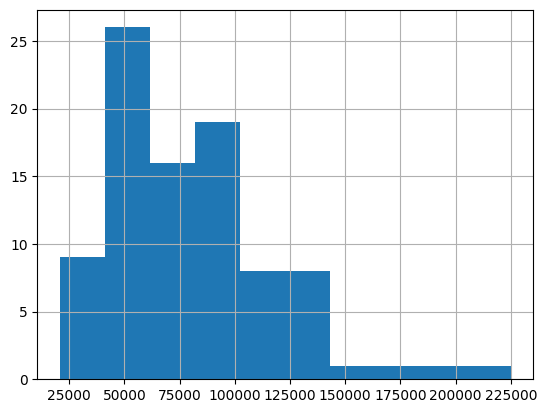

In [69]:
df['MEDIAN SALARY_ai'].hist()

<Axes: >

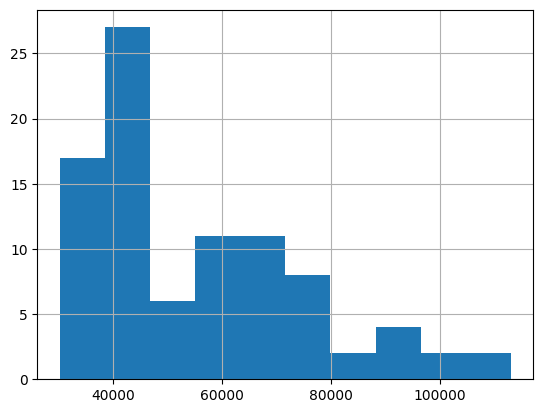

In [70]:
df['MEDIAN SALARY_non_ai'].hist()

<Axes: >

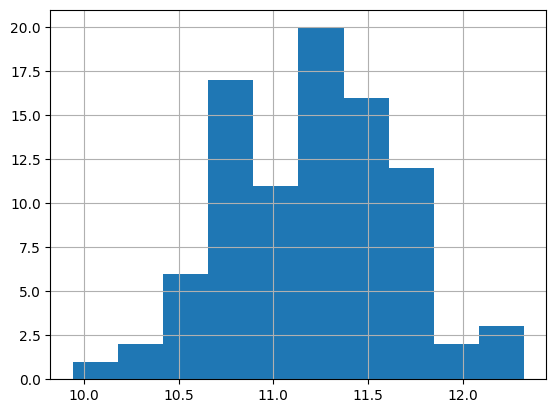

In [73]:
df['MEDIAN_LOG_SALARY_ai'].hist()

<Axes: >

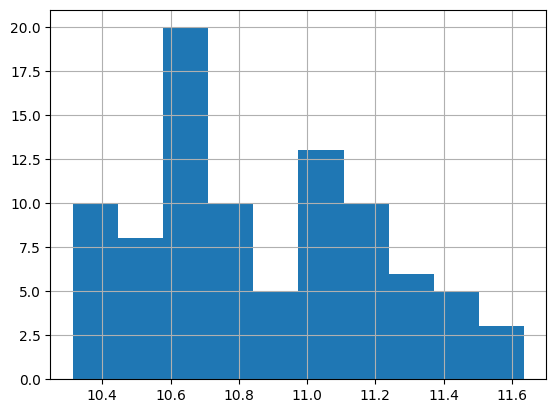

In [74]:
df['MEDIAN_LOG_SALARY_non_ai'].hist()

# Computer & Mathematical Occupations Dummy

In [82]:
df['Comp_Math_Occ'] = (df[occupation] == 'Computer and Mathematical Occupations').astype(int)

In [88]:
models5 = []
for benefit in benefits4:
    # benefit_df = df[df['Benefit'] == benefit].copy()
    benefit_df = df.copy()
    benefit_df.rename(columns={f'Prevalence: {benefits_labels_map[benefit]}': f'Overall Benefit Prevalence', 'LOG_SALARY_ai':'Mean Log AI Salary'}, inplace=True)
    if benefit == 'wfh_wham':
        benefit_df = benefit_df[benefit_df['YEAR'] != 2018]
    label = benefits_labels_map[benefit]
    X_cols = [f'Overall Benefit Prevalence', 'AI Demand', 'Comp_Math_Occ']
    y_col = [f'Prevalence: {label} (AI)']
    benefit_df = benefit_df.dropna(subset=X_cols + y_col)
    X = benefit_df[X_cols]
    y = benefit_df[y_col]
    year_dummies = pd.get_dummies(benefit_df['YEAR'], prefix = 'Year').drop(columns=['Year_2019'])
    # print(year_dummies)
    X = pd.concat([X, year_dummies], axis=1)
    X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})
    # print(X)
    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    print(benefit)
    # benefit_models.setdefault(benefit, []).append(model)
    models5.append(model)
    # Print the summary of the regression
    print(model.summary())

EDU_ASSISTANCE
                                     OLS Regression Results                                    
Dep. Variable:     Prevalence: Tuition Assistance (AI)   R-squared:                       0.567
Model:                                             OLS   Adj. R-squared:                  0.524
Method:                                  Least Squares   F-statistic:                     13.24
Date:                                 Fri, 01 Nov 2024   Prob (F-statistic):           4.82e-12
Time:                                         17:46:06   Log-Likelihood:                -203.86
No. Observations:                                   90   AIC:                             425.7
Df Residuals:                                       81   BIC:                             448.2
Df Model:                                            8                                         
Covariance Type:                             nonrobust                                         
                         

In [89]:
# Assume benefit_models is a list of models aligned with benefits4
stargazer = Stargazer(models5)

# Set custom column labels based on benefit names
stargazer.custom_columns(benefits4_labels, [1] * len(benefits4))  # `[1] * len(benefits4)` specifies that each label is for one column


# Render the HTML display with benefit names as model titles
display(HTML(stargazer.render_html()))


# 2024

In [ ]:
df_24 = 